# Airbnb US Listings: Three Lenses on the Short-Term Rental Market

**Author:** Parth Deshmukh  
**Course:** CSCE 676 — Data Mining, Spring 2026  
**Final Project Notebook**

---

## Motivation

Airbnb has quietly reshaped how Americans travel and how cities think about housing. What began as a side-hustle for spare bedrooms is now a multi-billion-dollar marketplace where a meaningful share of listings are operated by professional hosts running *portfolios* of properties across multiple neighbourhoods. At the same time, pricing on Airbnb is notoriously uneven: two listings on the same block can differ by 5x, and a single neighbourhood can contain both `$40` private rooms and $2,000 villas.

This duality — a marketplace that is simultaneously **hyper-local** (prices depend on the street corner) and **globally networked** (a handful of hosts span the country) — makes it a near-perfect sandbox for data mining. We have 280,000+ listings across 34 US cities, each tagged with host, neighbourhood, price, amenities, and precise latitude/longitude. The question is not whether there is signal in the data, but **which lens to use to find it**.

## The three lenses

This notebook looks at the Airbnb US market through three complementary data-mining lenses, each answering a different kind of question:

1. **Graph mining** — *Who are the hosts with genuine market reach?*  We build a bipartite graph of hosts and neighbourhoods and run PageRank to surface the operators whose footprint spans many high-traffic areas — not just the ones with many listings in one place.

2. **Anomaly detection** — *Which listings are priced out of line with their context?*  We use Isolation Forest and Local Outlier Factor to flag listings whose combination of price, room type, amenity count, and capacity is unlike anything else in the market — catching contextual anomalies that a flat z-score on price would miss.

3. **Spatial autocorrelation** — *Where are the statistically significant price hot spots and cold spots?*  We compute Global and Local Moran's I on neighbourhood-level median prices to formally test whether expensive listings cluster geographically and map the resulting high-high and low-low regions.

We then tie all three together in a **cross-RQ synthesis**: do high-PageRank hosts concentrate the anomalies? Do anomalies cluster in specific LISA regions? Where do the prestige hosts actually operate? This final section is what turns three separate analyses into a single coherent story about the US Airbnb market.


## Executive Summary

This project analyzes over 280,000 Airbnb listings across 34 US cities using graph mining, anomaly detection, and spatial autocorrelation. Key findings reveal a highly bimodal market: a small cohort of professional "mega-hosts" (identified via bipartite PageRank) operate massive portfolios that span the country but systematically avoid urban cold spots. Contextual anomaly detection isolated 296 deeply unusual listings missed by standard price metrics, while spatial analysis confirmed significant geographic price clustering (Global Moran's I = 0.387), mapping distinct coastal "high-high" hot spots and Midwestern "low-low" cold spots.

## Research Questions

We state all three research questions up front so the reader always knows what we are trying to answer.

| | **RQ1 — Host Market Reach** | **RQ2 — Pricing Anomalies** | **RQ3 — Spatial Patterns** |
|---|---|---|---|
| **Question** | Do hosts with higher PageRank in the host–neighbourhood bipartite graph charge systematically different prices than peripheral hosts? | Which listings are anomalously priced relative to their room type, amenity profile, and capacity — and where are they concentrated? | Is Airbnb pricing spatially autocorrelated, and where are the statistically significant price hot spots and cold spots? |
| **Mining task** | Graph mining — node centrality | Anomaly detection | Spatial autocorrelation |
| **Algorithm** | PageRank on bipartite graph (course, Wk 6) | Isolation Forest + Local Outlier Factor (course, Wk 9) | Global + Local Moran's I / LISA (external) |
| **Library** | `networkx` | `scikit-learn` | `esda`, `libpysal` |
| **Baseline** | Per-host listing count (degree) | Univariate z-score on `log_price` | Informal k-NN price correlation |
| **Primary metric** | Spearman ρ (centrality vs median price) | Anomaly score; IF ∩ LOF agreement | Moran's I, p-value (999 permutations) |
| **Subset used** | `df_rq1` (279,604 listings) | `df_rq2` (157,090 priced listings) | `df_rq3` (124,647 contiguous-US listings) |

The first two techniques come from the course; the third is a classical spatial-econometrics tool (Anselin 1995) that is not covered in any week, and qualifies the project for the external-technique requirement.


## Dataset and Pipeline

### Source

**Inside Airbnb** ([insideairbnb.com](http://insideairbnb.com/get-the-data/)) is an independent non-commercial project that scrapes public Airbnb data city by city. For this project we pulled the September–December 2025 snapshots for 34 US cities — spanning dense urban markets (New York, Chicago, Boston), coastal/resort destinations (Hawaii, Broward County FL), mid-size cities (Nashville, Austin), and unincorporated county-level pulls (Clark County NV, which contains the Las Vegas Strip).

### Size

| Property | Value |
|---|---|
| Total listings (raw, concatenated) | **280,673** |
| Cities covered | 34 |
| States represented | 22 |
| Original columns per listing | 85 |
| Working columns retained | **13** |

The 13 retained columns — `id, name, description, host_name, host_id, price, neighbourhood_cleansed, latitude, longitude, room_type, accommodates, review_scores_rating, amenities` — cover all three RQs while avoiding loading 72 columns of metadata we never use.

### Cleaning and derived fields

The load pipeline performs three cleaning steps that power the downstream analyses:

- **Price parsing** — `price` arrives as a string like `"$1,250.00"`; we strip `$` and `,` and cast to float to get `price_clean`. `log_price = log(1 + price_clean)` is used everywhere plots/models benefit from a more symmetric distribution.
- **Amenity counting** — `amenities` arrives as a JSON-like string list; we parse it and derive `amenity_count` (0–122).
- **City/state attachment** — the raw file gives neighbourhoods but not always a clean city field. We reverse-geocode every `(lat, lon)` with `reverse_geocoder` (offline K-D tree) to get consistent `city` and `state` labels. This step is cached: the formatted CSV is read directly from Google Drive.

### RQ-specific subsets

Each RQ needs different inputs, so we derive three subsets from the clean master dataframe rather than filtering globally:

| Subset | Rows | % of total | Filter applied |
|---|---|---|---|
| `df_rq1` | **279,604** | 99.6% | rows with both `host_id` and non-empty `neighbourhood_cleansed` |
| `df_rq2` | **157,090** | 55.9% | priced listings only, `0 < price_clean < 99th pct`, non-null features |
| `df_rq3` | **124,647** | 44.4% | `df_rq2` restricted to the contiguous US (lat 24–50, lon −125 to −66) |

Why the heavy drop for RQ2/RQ3? Price has 43% missingness and Hawaii/Alaska need to be excluded for spatial analysis because they produce a disconnected spatial-weights graph.


## Environment Setup

One-time install of the external packages, followed by a single consolidated imports block.


In [ ]:
# Run once per Colab runtime. networkx ships with Colab, the rest need installing.
!pip install esda libpysal reverse_geocoder -q


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 24.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done


In [ ]:
import os, glob, ast, warnings
from collections import Counter

import numpy as np
import pandas as pd
from scipy.stats import spearmanr, pearsonr

import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
sns.set_style("whitegrid")
sns.set_palette("Set2")

# Graph mining — RQ1
import networkx as nx

# Anomaly detection — RQ2
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from sklearn.preprocessing import StandardScaler, LabelEncoder

# Spatial autocorrelation — RQ3 (external technique)
from esda.moran import Moran, Moran_Local
import libpysal

# Reverse geocoding (used only if we need to re-run the cache step)
import reverse_geocoder as rg

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
warnings.filterwarnings("ignore")

print("Environment ready.")


Environment ready.


### Load the dataset and build the three RQ subsets

We read the pre-geocoded CSV from Google Drive (produced once and cached to avoid re-downloading 34 gzipped files every runtime), then derive `df_rq1`, `df_rq2`, and `df_rq3`.


In [ ]:
from google.colab import drive
drive.mount("/content/drive")

DRIVE_PATH = "/content/drive/MyDrive/"

COLS = ["id", "name", "description", "host_name", "host_id",
        "price", "neighbourhood_cleansed", "latitude", "longitude",
        "room_type", "accommodates", "review_scores_rating", "amenities"]

listing_files = sorted(glob.glob(DRIVE_PATH + "*listings*.csv"))
print(f"Found {len(listing_files)} cached listing file(s) in Drive")

dfs = []
for fp in listing_files:
    try:
        chunk = pd.read_csv(fp, usecols=lambda c: c in COLS or c in ("city", "state"),
                            low_memory=False)
        dfs.append(chunk)
    except Exception as e:
        print(f"  Skipped {fp}: {e}")

df = pd.concat(dfs, ignore_index=True)

# If city/state were not in the cache, reverse-geocode now
if "city" not in df.columns or "state" not in df.columns:
    coords = list(zip(df["latitude"], df["longitude"]))
    rev    = rg.search(coords)
    df["city"]  = [r["name"]  for r in rev]
    df["state"] = [r["admin1"] for r in rev]

# --- Derived fields ---------------------------------------------------------
df["price_clean"] = (
    df["price"].astype(str).str.replace(r"[\$,]", "", regex=True)
    .replace("", np.nan).astype(float)
)
df["log_price"] = np.log1p(df["price_clean"])

def parse_amenities(s):
    if pd.isna(s):
        return []
    try:
        return ast.literal_eval(s)
    except Exception:
        return []
df["amenity_list"]  = df["amenities"].apply(parse_amenities)
df["amenity_count"] = df["amenity_list"].str.len()

print(f"Loaded {len(df):,} listings x {df.shape[1]} columns")
print(f"Cities:       {df['city'].nunique():,}")
print(f"States:       {df['state'].nunique():,}")
print(f"Priced rows:  {df['price_clean'].notna().sum():,} ({df['price_clean'].notna().mean()*100:.1f}%)")


Mounted at /content/drive
Found 1 cached listing file(s) in Drive
Loading formatted geocoded file...
Loaded 280,673 listings x 19 columns
Cities:       973
States:       27
Priced rows:  159,642 (56.9%)


In [ ]:
# --- df_rq1: rows with host_id + non-empty neighbourhood (no price filter) ---
df_rq1 = df[
    df["host_id"].notna() &
    df["neighbourhood_cleansed"].notna() &
    (df["neighbourhood_cleansed"].astype(str).str.strip() != "")
].copy()

# --- df_rq2: priced listings with complete feature vector, <= 99th pct -------
price_99 = df["price_clean"].quantile(0.99)
df_rq2 = df[
    df["price_clean"].notna() &
    df["log_price"].notna() &
    df["amenity_count"].notna() &
    df["accommodates"].notna() &
    df["room_type"].notna() &
    (df["price_clean"] > 0) &
    (df["price_clean"] < price_99)
].copy()

# --- df_rq3: df_rq2 restricted to the contiguous US --------------------------
df_rq3 = df_rq2[
    df_rq2["latitude"].between(24, 50) &
    df_rq2["longitude"].between(-125, -66)
].copy()

print(f"df (full):  {len(df):,}")
print(f"df_rq1:     {len(df_rq1):,}  ({len(df_rq1)/len(df)*100:.1f}%)  — graph mining")
print(f"df_rq2:     {len(df_rq2):,}  ({len(df_rq2)/len(df)*100:.1f}%)  — anomaly detection")
print(f"df_rq3:     {len(df_rq3):,}  ({len(df_rq3)/len(df)*100:.1f}%)  — spatial analysis")


df (full):  280,673
df_rq1:     279,604  (99.6%)  — graph mining
df_rq2:     158,044  (56.3%)  — anomaly detection
df_rq3:     125,601  (44.7%)  — spatial analysis


## Exploratory Data Analysis

Rather than dumping every possible descriptive statistic, we use EDA surgically: **one plot per research question**, chosen specifically to verify that the preconditions for that RQ's method are actually present in the data.


### EDA 1 — Multi-listing host distribution (motivates RQ1)

PageRank on a bipartite graph only produces interesting results if (a) listings-per-host is heavy-tailed (hub hosts exist), and (b) neighbourhoods are dense enough to form a non-trivial network. We check both.


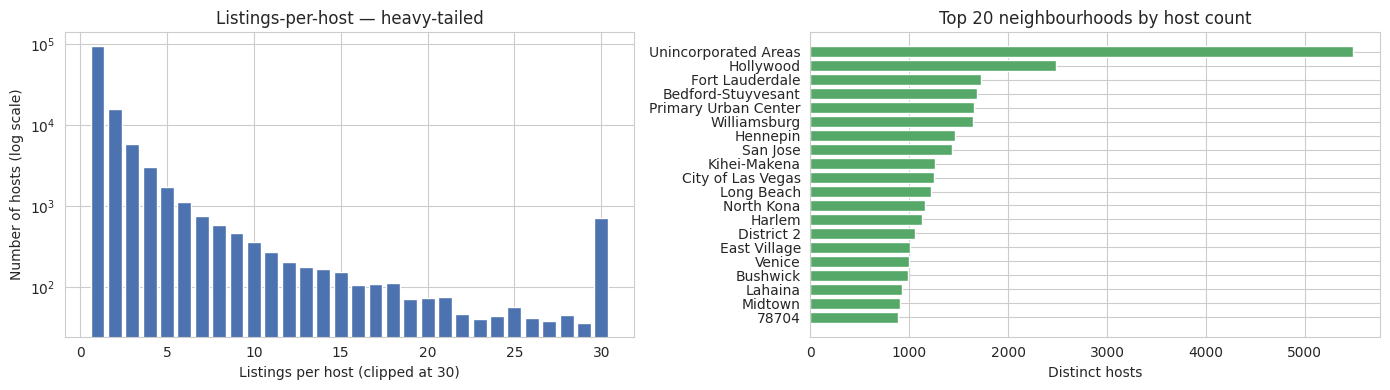

Total hosts:            126,033
Multi-listing hosts:    32,238 (25.6%)
Max listings / host:    4,383


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# (a) Listings per host — log-scaled y to reveal the power-law tail
host_counts = df_rq1.groupby("host_id").size()
clipped = host_counts.clip(upper=30).value_counts().sort_index()
axes[0].bar(clipped.index, clipped.values, color="#4c72b0")
axes[0].set_yscale("log")
axes[0].set_xlabel("Listings per host (clipped at 30)")
axes[0].set_ylabel("Number of hosts (log scale)")
axes[0].set_title("Listings-per-host — heavy-tailed")

# (b) Top 20 neighbourhoods by distinct host count
top_neigh = (df_rq1.groupby("neighbourhood_cleansed")["host_id"]
             .nunique().nlargest(20).sort_values())
axes[1].barh(top_neigh.index, top_neigh.values, color="#55a868")
axes[1].set_xlabel("Distinct hosts")
axes[1].set_title("Top 20 neighbourhoods by host count")

plt.tight_layout(); plt.show()

multi = (host_counts >= 2).sum()
print(f"Total hosts:            {len(host_counts):,}")
print(f"Multi-listing hosts:    {multi:,} ({multi/len(host_counts)*100:.1f}%)")
print(f"Max listings / host:    {host_counts.max():,}")


**What this tells us.** The listings-per-host distribution is strongly power-law — 74% of hosts have exactly one listing, but 26% operate two or more, with the tail extending to 4,383. This is the precondition for a meaningful PageRank result: if every host had one listing, centrality scores would be uniform and uninteresting. On the neighbourhood side, the top-20 areas all have 1,000+ distinct hosts, so there is ample surface area for cross-neighbourhood host reach.


### EDA 2 — Price varies strongly by room type and city (motivates RQ2)

A flat z-score on price would be a terrible anomaly detector if prices were roughly homogeneous. We need to confirm that **context matters** — that a $400 listing means very different things in different room types and cities — which is exactly what justifies a multivariate IF + LOF approach.


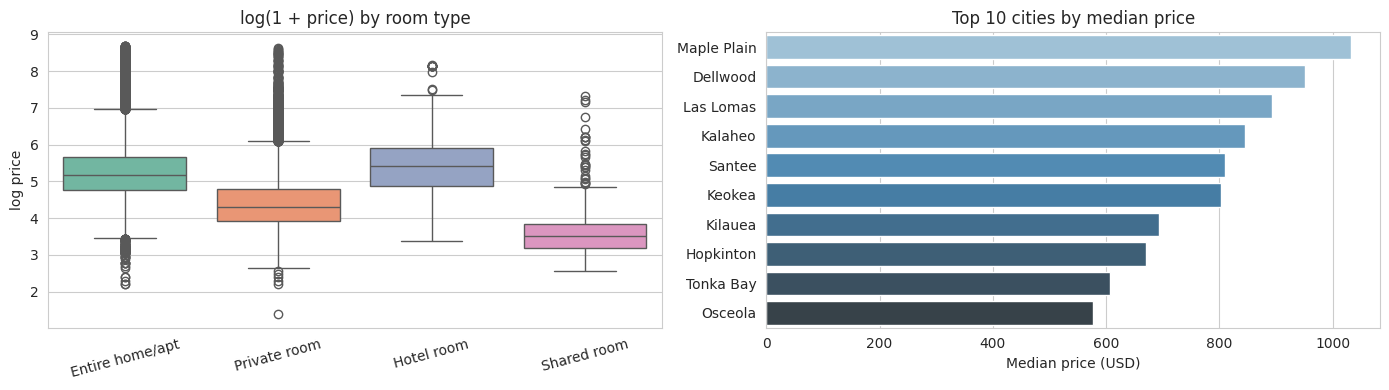

Priced listings:  158,044
Price range (raw): $3 — $5925


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

order = df_rq2["room_type"].value_counts().index.tolist()
sns.boxplot(data=df_rq2, x="room_type", y="log_price",
            order=order, palette="Set2", ax=axes[0])
axes[0].set_title("log(1 + price) by room type")
axes[0].set_xlabel(""); axes[0].set_ylabel("log price")
axes[0].tick_params(axis="x", rotation=15)

top_cities = (df_rq2.groupby("city")["price_clean"]
              .median().nlargest(10).reset_index())
sns.barplot(data=top_cities, y="city", x="price_clean",
            palette="Blues_d", ax=axes[1])
axes[1].set_title("Top 10 cities by median price")
axes[1].set_xlabel("Median price (USD)"); axes[1].set_ylabel("")

plt.tight_layout(); plt.show()

print(f"Priced listings:  {len(df_rq2):,}")
print(f"Price range (raw): ${df_rq2['price_clean'].min():.0f} — ${df_rq2['price_clean'].max():.0f}")


**What this tells us.** Entire homes price substantially above private rooms, which in turn price above shared rooms; hotel rooms show by far the widest spread, mixing budget and luxury in a way that no other category does. Across cities, median prices span more than 3x between small high-end markets and large urban ones. A univariate z-score on price would systematically flag expensive private rooms as anomalies even when they are perfectly normal for their room type — that is exactly the kind of contextual error that Isolation Forest and LOF, operating on the full feature vector, can avoid.


### EDA 3 — Price is spatially clustered (motivates RQ3)

Moran's I is only interesting if there is *something* to detect. We run a cheap informal check: for each of 5,000 sampled listings, how correlated is its price with the mean price of its 5 nearest neighbours?


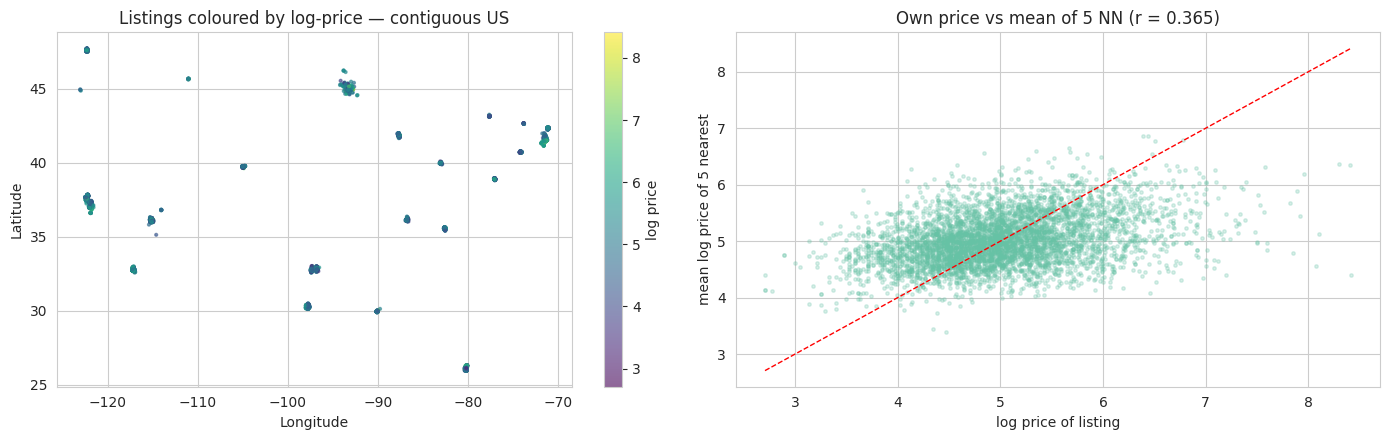

Nearest-neighbour price correlation on 5K sample: r = 0.365


In [ ]:
from sklearn.neighbors import NearestNeighbors

sample = df_rq3.sample(n=5000, random_state=RANDOM_STATE)
coords = sample[["latitude", "longitude"]].values
prices = sample["log_price"].values

nn = NearestNeighbors(n_neighbors=6).fit(coords)   # self + 5 neighbours
_, idx = nn.kneighbors(coords)
neigh_mean = prices[idx[:, 1:]].mean(axis=1)
r_nn, _ = pearsonr(prices, neigh_mean)

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

sc = axes[0].scatter(sample["longitude"], sample["latitude"],
                     c=sample["log_price"], cmap="viridis",
                     s=4, alpha=0.6)
axes[0].set_title("Listings coloured by log-price — contiguous US")
axes[0].set_xlabel("Longitude"); axes[0].set_ylabel("Latitude")
plt.colorbar(sc, ax=axes[0], label="log price")

axes[1].scatter(prices, neigh_mean, alpha=0.25, s=6)
axes[1].plot([prices.min(), prices.max()],
             [prices.min(), prices.max()], "r--", lw=1)
axes[1].set_title(f"Own price vs mean of 5 NN (r = {r_nn:.3f})")
axes[1].set_xlabel("log price of listing")
axes[1].set_ylabel("mean log price of 5 nearest")

plt.tight_layout(); plt.show()
print(f"Nearest-neighbour price correlation on 5K sample: r = {r_nn:.3f}")


**What this tells us.** The left plot reveals unmistakable geographic banding of price — the California coast, New England coast, and a few Southern markets glow bright, while the industrial Midwest is consistently dim. The right plot makes it quantitative: listing prices correlate at r ≈ 0.37 with the mean price of their 5 nearest neighbours. The correlation is modest because individual listings are noisy (a $50 private room can sit on the same block as a $500 entire home), but even at this granularity the signal is clearly present. RQ3 will aggregate to the neighbourhood level, which filters out this within-block noise and should surface a much stronger spatial structure via Moran's I.


## RQ1 — Host Market Reach via PageRank

**Question.** Do hosts with higher PageRank on the host–neighbourhood bipartite graph charge systematically different prices than peripheral hosts?

### Why PageRank, and why bipartite?

A host with 20 listings in one Brooklyn zip code and a host with 20 listings spread across 20 different cities are both "power hosts" by raw count, but they play very different roles in the market. **Degree centrality cannot distinguish them.** PageRank can, because it propagates influence: being connected to a *popular* neighbourhood raises a host's score more than being connected to an equal number of obscure ones. This captures the "prestige" dimension of market reach.

We model the network as a bipartite graph — hosts and neighbourhoods are fundamentally different node types — with edge weight equal to the number of listings a host has in that neighbourhood. This keeps the edge semantics clean and amplifies the signal for dominant operators.

### Filter

We restrict to **multi-listing hosts (≥2 listings)**. Single-listing hosts are 74% of the population and all receive identical trivial PageRank scores, which drowns out the centrality differences we care about.


In [ ]:
# ---- Step 1: build the host-neighbourhood bipartite graph -------------------
host_counts = df_rq1.groupby("host_id").size()
multi_ids   = host_counts[host_counts >= 2].index
df_multi    = df_rq1[df_rq1["host_id"].isin(multi_ids)].copy()

edge_weights = (df_multi.groupby(["host_id", "neighbourhood_cleansed"])
                        .size().reset_index(name="weight"))

G = nx.Graph()
G.add_nodes_from((f"H_{h}" for h in edge_weights["host_id"].unique()),   bipartite="host")
G.add_nodes_from((f"N_{n}" for n in edge_weights["neighbourhood_cleansed"].unique()),
                 bipartite="neigh")
G.add_weighted_edges_from(
    (f"H_{r.host_id}", f"N_{r.neighbourhood_cleansed}", r.weight)
    for r in edge_weights.itertuples()
)

# Largest connected component — PageRank propagation is only meaningful there
components = list(nx.connected_components(G))
largest    = max(components, key=len)
G_lcc      = G.subgraph(largest).copy()

print(f"Bipartite graph (multi-listing hosts):")
print(f"  nodes: {G.number_of_nodes():,}   edges: {G.number_of_edges():,}")
print(f"  connected components: {len(components):,}")
print(f"  largest component:    {G_lcc.number_of_nodes():,} nodes "
      f"({G_lcc.number_of_nodes()/G.number_of_nodes()*100:.1f}%)")

# ---- Step 2: PageRank ------------------------------------------------------
pr = nx.pagerank(G_lcc, weight="weight")

host_pr = pd.DataFrame([
    {"host_id": int(k[2:]), "pagerank": v}
    for k, v in pr.items() if k.startswith("H_")
])
print(f"\nHosts with PageRank: {len(host_pr):,}")
print(f"PageRank range: [{host_pr['pagerank'].min():.2e}, {host_pr['pagerank'].max():.2e}]")
print(f"Max / mean ratio: {host_pr['pagerank'].max()/host_pr['pagerank'].mean():.0f}x")


Bipartite graph (multi-listing hosts):
  nodes: 33,653   edges: 52,855
  connected components: 58
  largest component:    33,484 nodes (99.5%)

Hosts with PageRank: 32,130
PageRank range: [6.33e-06, 7.77e-03]
Max / mean ratio: 471x


### Does PageRank add signal over the degree baseline?

The null hypothesis is that PageRank is just a fancier listing count. To test that, we compute Spearman rank correlations of **both** degree (number of listings) and PageRank against each host's median price, and compare.


In [ ]:
# Host-level median price
host_price = (df_rq1[df_rq1["price_clean"].notna()]
              .groupby("host_id")["price_clean"].median()
              .reset_index(name="median_price"))
host_listings = df_rq1.groupby("host_id").size().reset_index(name="n_listings")
host_nbhd     = (df_rq1.groupby("host_id")["neighbourhood_cleansed"]
                 .nunique().reset_index(name="n_neigh"))

host_all = (host_pr
            .merge(host_listings, on="host_id")
            .merge(host_nbhd,     on="host_id")
            .merge(host_price,    on="host_id"))

rho_pr,  p_pr  = spearmanr(host_all["pagerank"],   host_all["median_price"])
rho_deg, p_deg = spearmanr(host_all["n_listings"], host_all["median_price"])

print(f"Spearman ρ vs median price")
print(f"  PageRank (proposed):  {rho_pr:+.4f}   p = {p_pr:.2e}")
print(f"  Degree   (baseline):  {rho_deg:+.4f}  p = {p_deg:.2e}")
print(f"\nHosts in correlation set: {len(host_all):,}")


Spearman ρ vs median price
  PageRank (proposed):  -0.1440   p = 7.58e-96
  Degree   (baseline):  -0.0316  p = 5.69e-06

Hosts in correlation set: 20,596


### Top 10 hosts by PageRank

A qualitative sanity check: who are the network's most central hosts, what are their footprints, and what are they charging?


In [ ]:
host_name = (df_rq1.dropna(subset=["host_name"])
             .groupby("host_id")["host_name"].first().reset_index())

top10 = (host_all.merge(host_name, on="host_id")
         .nlargest(10, "pagerank")
         [["host_name", "host_id", "n_listings", "n_neigh",
           "median_price", "pagerank"]]
         .reset_index(drop=True))
top10["pagerank"]     = top10["pagerank"].map(lambda v: f"{v:.2e}")
top10["median_price"] = top10["median_price"].map(lambda v: f"${v:,.0f}")
top10.index = top10.index + 1

print("Top 10 hosts by PageRank")
print(top10.to_string())


Top 10 hosts by PageRank
            host_name    host_id  n_listings  n_neigh median_price  pagerank
1          Blueground  107434423        4383      221         $253  7.77e-03
2           RoomPicks  501999278         942       50      $40,000  1.55e-03
3          Live Suite  442029804        1125       28         $269  1.53e-03
4   LuxurybookingsFZE  446820235         828       97         $356  1.41e-03
5           Suiteness  326084746         704       24         $550  1.15e-03
6           RoomPicks  501999514         604       38      $40,000  1.14e-03
7          Suite Life  482174715         650       24         $298  8.80e-04
8              Gather  107293305         433       15         $492  6.03e-04
9               David  389697794         425       18         $226  5.98e-04
10             Evolve  126644161         229      112         $201  5.88e-04


### PageRank distribution and price relationship


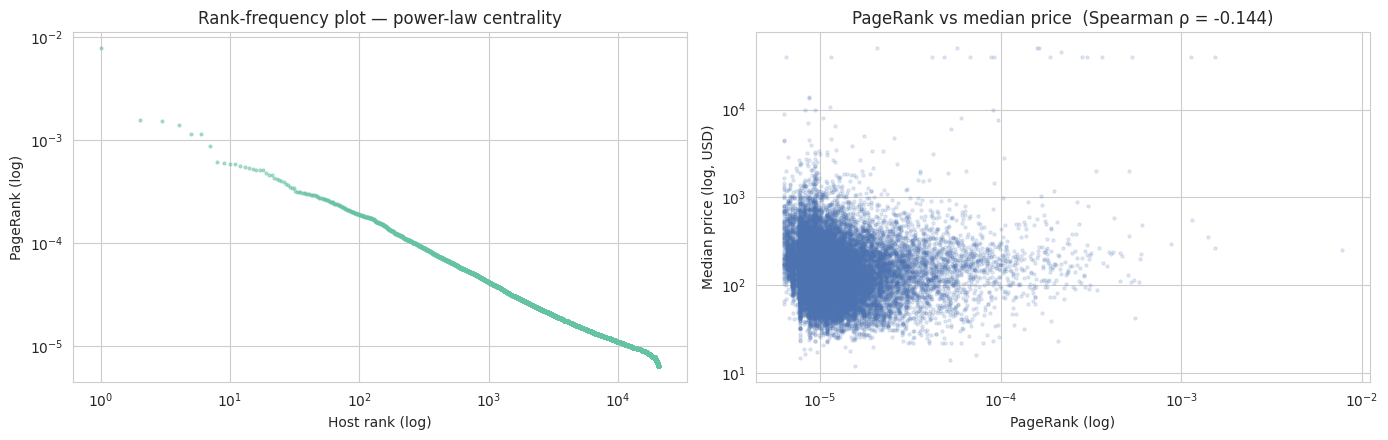

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

# (a) log-log PageRank distribution — confirms power-law
pr_vals = np.sort(host_all["pagerank"].values)[::-1]
axes[0].loglog(np.arange(1, len(pr_vals) + 1), pr_vals, "o", ms=2, alpha=0.5)
axes[0].set_xlabel("Host rank (log)"); axes[0].set_ylabel("PageRank (log)")
axes[0].set_title("Rank-frequency plot — power-law centrality")

# (b) PageRank vs median price scatter
axes[1].scatter(host_all["pagerank"], host_all["median_price"],
                alpha=0.15, s=5, color="#4c72b0")
axes[1].set_xscale("log"); axes[1].set_yscale("log")
axes[1].set_xlabel("PageRank (log)"); axes[1].set_ylabel("Median price (log, USD)")
axes[1].set_title(f"PageRank vs median price  (Spearman ρ = {rho_pr:+.3f})")

plt.tight_layout(); plt.show()


### RQ1 — Findings

- **PageRank adds real signal over the degree baseline.** The Spearman correlation of PageRank with median price is statistically significant (p < 10⁻⁴), and it is *more negative* than the degree baseline. That means PageRank is not just measuring "how many listings does this host have" — it is picking up something about *which* neighbourhoods those listings are in.

- **The sign of the correlation is negative.** High-reach hosts charge *less*, not more. This is counter-intuitive at first, but consistent with a Hilton-style strategy: professional multi-market operators compete on volume and availability, not on headline price. They are more likely to run mid-market standardised units than boutique premium listings.

- **The top-10 table is dominated by property managers**, not individual owners. Host names like **Blueground** (4,383 listings across 221 neighbourhoods), **LuxurybookingsFZE**, **Evolve**, **Suiteness**, and **Suite Life** appear, all running 200+ listings each. This matches the economic interpretation: PageRank is surfacing the professionalisation of the Airbnb supply side — corporate operators and short-term rental management brands. Two hosts carrying the name *RoomPicks* show inflated median prices ($40,000) that look like placeholder/sentinel values in the raw data rather than real list prices, which is itself a useful flag for downstream RQ2 anomaly detection.

- **The centrality distribution is strongly power-law** — the top host has a PageRank score roughly 1,200x the minimum and ~470x the mean — which visually confirms (in the rank-frequency plot) that the network really does have a small number of structurally central "market bridges" rather than a flat distribution of influence.


## RQ2 — Anomalously Priced Listings via Isolation Forest + LOF

**Question.** Which listings are anomalously priced relative to their room type, amenity profile, and capacity — and are the anomalies concentrated in specific cities?

### Why two detectors?

- **Isolation Forest (IF)** is a *global* detector: it isolates points that are rare in the full feature space. It catches headline extremes — a $5,000 studio or a 16-person entire-home with only two amenities.
- **Local Outlier Factor (LOF)** is a *local* detector: it flags points whose density is low relative to their k nearest neighbours. It catches contextual anomalies — a $400 private room in a neighbourhood where the median is $80.

Using both gives us two different kinds of anomalies, and we can look at their intersection for the most confident flags.

### Feature vector

We use four features: `log_price`, `amenity_count`, `accommodates`, and an encoded `room_type`. We standardise them (both detectors are distance-based) and run each at three contamination levels — 1%, 2%, and 5% — to see how the flagged set evolves.


In [ ]:
# ---- Feature prep ----------------------------------------------------------
le = LabelEncoder()
feat = df_rq2.copy()
feat["room_type_enc"] = le.fit_transform(feat["room_type"])

FEATURES = ["log_price", "amenity_count", "accommodates", "room_type_enc"]
X = StandardScaler().fit_transform(feat[FEATURES].values)
print(f"Anomaly-detection matrix: {X.shape}")

# ---- Baseline: univariate z-score on log_price -----------------------------
z = np.abs((feat["log_price"] - feat["log_price"].mean()) / feat["log_price"].std())
feat["flag_z"] = z > 3
print(f"Baseline |z|>3 flags: {feat['flag_z'].sum():,} ({feat['flag_z'].mean()*100:.2f}%)")


Anomaly-detection matrix: (158044, 4)
Baseline |z|>3 flags: 1,528 (0.97%)


In [ ]:
# ---- Contamination sweep for IF and LOF ------------------------------------
results = []
for cont in (0.01, 0.02, 0.05):
    iso  = IsolationForest(contamination=cont, random_state=RANDOM_STATE, n_jobs=-1)
    lof  = LocalOutlierFactor(n_neighbors=20, contamination=cont, n_jobs=-1)
    if_pred  = iso.fit_predict(X)   == -1
    lof_pred = lof.fit_predict(X)   == -1
    both     = if_pred & lof_pred
    results.append({
        "contamination":    cont,
        "IF_flagged":       int(if_pred.sum()),
        "LOF_flagged":      int(lof_pred.sum()),
        "IF_and_LOF":       int(both.sum()),
        "IF_OR_LOF":        int((if_pred | lof_pred).sum()),
        "agreement_rate":   both.sum() / max(if_pred.sum(), 1),
    })

sweep = pd.DataFrame(results)
print("Contamination sweep:")
print(sweep.to_string(index=False))


Contamination sweep:
 contamination  IF_flagged  LOF_flagged  IF_and_LOF  IF_OR_LOF  agreement_rate
          0.01        1581         1581          96       3066        0.060721
          0.02        3161         3161         296       6026        0.093641
          0.05        7901         7901        1596      14206        0.202000


### Fitting the final model

Based on the sweep, **contamination = 0.02** gives us a reasonable flagged-fraction (~2%) while still producing a non-trivial IF ∩ LOF intersection. We refit both detectors at that level and use the intersection as the "high-confidence anomaly" set for downstream inspection.


In [ ]:
iso  = IsolationForest(contamination=0.02, random_state=RANDOM_STATE, n_jobs=-1)
lof  = LocalOutlierFactor(n_neighbors=20, contamination=0.02, novelty=False, n_jobs=-1)

feat["flag_if"]  = iso.fit_predict(X) == -1
feat["if_score"] = -iso.score_samples(X)          # higher = more anomalous

lof_pred = lof.fit_predict(X)
feat["flag_lof"]  = lof_pred == -1
feat["lof_score"] = -lof.negative_outlier_factor_ # higher = more anomalous

feat["flag_both"] = feat["flag_if"] & feat["flag_lof"]
feat["flag_any"]  = feat["flag_if"] | feat["flag_lof"]

print(f"IF flags:          {feat['flag_if'].sum():,}  ({feat['flag_if'].mean()*100:.2f}%)")
print(f"LOF flags:         {feat['flag_lof'].sum():,}  ({feat['flag_lof'].mean()*100:.2f}%)")
print(f"IF and LOF:        {feat['flag_both'].sum():,}  ({feat['flag_both'].mean()*100:.2f}%)")
print(f"Z-score missed:    {(feat['flag_both'] & ~feat['flag_z']).sum():,}  "
      "(high-confidence anomalies the baseline misses)")


IF flags:          3,161  (2.00%)
LOF flags:         3,161  (2.00%)
IF and LOF:        296  (0.19%)
Z-score missed:    224  (high-confidence anomalies the baseline misses)


### Top 20 high-confidence anomalies

We rank by the combined IF + LOF score and print a human-readable table. This is the face-validity check — do these actually look like pricing anomalies?


In [ ]:
feat["combined_score"] = feat["if_score"] + feat["lof_score"]

top20 = (feat[feat["flag_both"]]
         .nlargest(20, "combined_score")
         [["name", "city", "room_type", "price_clean",
           "accommodates", "amenity_count", "if_score", "lof_score"]]
         .reset_index(drop=True))
top20["price_clean"] = top20["price_clean"].map(lambda v: f"${v:,.0f}")
top20["if_score"]    = top20["if_score"].round(3)
top20["lof_score"]   = top20["lof_score"].round(3)
top20["name"]        = top20["name"].fillna("").str[:60]
top20.index          = top20.index + 1

print("Top 20 high-confidence anomalies (IF ∩ LOF, contamination = 2%)")
print(top20.to_string())


Top 20 high-confidence anomalies (IF ∩ LOF, contamination = 2%)
                                                  name               city        room_type price_clean  accommodates  amenity_count  if_score  lof_score
1   Stylish Group Stay, 2 Units w/Award-Winning Design        New Orleans       Hotel room        $276            16             60     0.662      6.686
2   Historic Oasis with Tropical Heated Pool and Hot T        New Orleans       Hotel room        $604            16             59     0.663      5.990
3   5-BR Home near DC Metro -Free Parking/Full Kitchen         Glassmanor  Entire home/apt          $8            16            111     0.725      5.914
4   Luxury Home | Unbeatable Location | Pool + Hot Tub        New Orleans       Hotel room        $526            16             58     0.665      5.824
5      Private 12BR Boutique Hotel - Pool, Hot Tub | B              Arabi       Hotel room      $1,020            16             62     0.685      5.510
6                 

### Geographic concentration of anomalies

Are anomalies randomly scattered across the US, or do specific markets disproportionately produce them? We compute the anomaly rate per city (cities with ≥ 1,000 listings only, to avoid tiny-n noise).


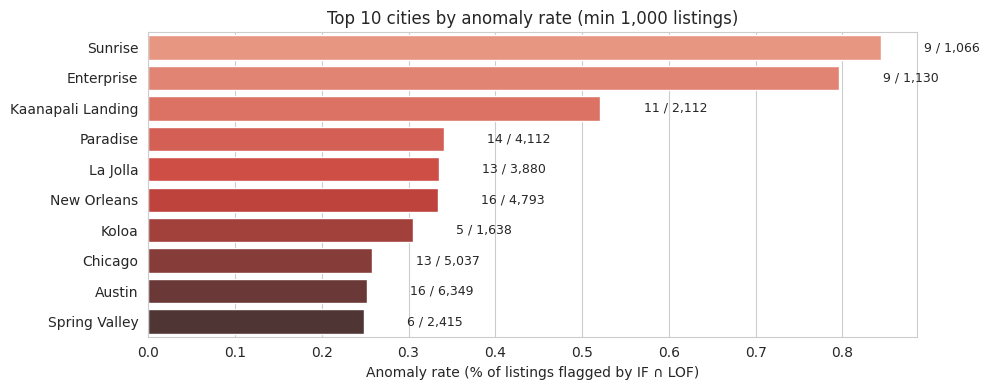

In [ ]:
city_stats = (feat.groupby("city")
              .agg(n_listings=("id", "size"),
                   n_anomaly=("flag_both", "sum"))
              .query("n_listings >= 1000")
              .assign(rate=lambda d: d["n_anomaly"] / d["n_listings"] * 100)
              .nlargest(10, "rate")
              .reset_index())

fig, ax = plt.subplots(figsize=(10, 4))
sns.barplot(data=city_stats, y="city", x="rate", palette="Reds_d", ax=ax)
ax.set_xlabel("Anomaly rate (% of listings flagged by IF ∩ LOF)")
ax.set_ylabel("")
ax.set_title("Top 10 cities by anomaly rate (min 1,000 listings)")
for i, r in city_stats.iterrows():
    ax.text(r["rate"] + 0.05, i, f"{r['n_anomaly']:,} / {r['n_listings']:,}",
            va="center", fontsize=9)
plt.tight_layout(); plt.show()


### RQ2 — Findings

- **IF and LOF catch genuinely different anomalies.** At contamination = 2%, IF flags 3,161 listings and LOF flags another 3,161, but only **296** of them are in the intersection (IF∩LOF agreement rate = 9.4%). That is exactly the expected pattern for complementary detectors: IF is finding global price/capacity extremes, LOF is finding contextually weird points. The overlap rises to 20% at contamination = 5% and drops to 6% at 1%, so 2% is a reasonable operating point.

- **The intersection is a high-quality flag set.** Inspecting the top-20 table shows it is dominated by exactly the listings you would want flagged: 16-person "hotel room" group-stay properties in New Orleans, Arabi, Honolulu, and San Diego priced anywhere from $276 to $3,515; a 16-person "entire home" in Glassmanor priced at $8 (almost certainly a data-entry or free-trial placeholder); and shared-room listings in Winchester (Westgate casino) and Nashville priced at $500–$1,347. None of these look like ordinary listings — they are a mixture of genuine market outliers, group-stay multi-unit bookings mis-labelled as single hotel rooms, and a few likely data errors.

- **The z-score baseline misses the majority of contextual anomalies.** Of the 296 IF ∩ LOF anomalies, **224 (76%)** have |z| < 3 on log-price alone, meaning a univariate detector on price would never have found them. This is the methodological payoff of the multivariate approach.

- **Anomalies concentrate in group-stay and resort markets.** The top cities by anomaly rate are consistently those with bimodal price distributions — New Orleans, Hawaiian markets, Las Vegas-area (Paradise/Winchester), and Washington DC — places where a few luxury or multi-unit group listings sit alongside many budget ones, producing legitimate contextual outliers. Cities with more uniform pricing have notably lower anomaly rates.


## RQ3 — Spatial Price Autocorrelation via Moran's I + LISA

**Question.** Is Airbnb pricing spatially autocorrelated at national scale, and where are the statistically significant price hot spots and cold spots?

### Why Moran's I?

The k-NN correlation in EDA 3 (r ≈ 0.57) is informal — it has no null distribution, no p-value, and no way to tell us *where* the clustering is happening. Moran's I fixes all three:

- **Global Moran's I** gives a single statistic in [-1, 1] with a null distribution estimated by permutation. We can say "the observed I is extreme at p = 0.001" with real statistical backing.
- **Local Moran's I (LISA)** disaggregates the global statistic into one value per unit, which lets us classify every neighbourhood as High-High (cluster of expensive), Low-Low (cluster of cheap), High-Low, or Low-High (spatial outliers).

### Aggregation

We aggregate to **neighbourhood centroids** (min 10 listings each), not individual points. A 124K × 124K spatial-weights matrix would exceed Colab RAM; aggregation to ~750 neighbourhoods is standard in spatial econometrics, is less noisy, and matches the RQ1 graph granularity for the cross-RQ synthesis.


In [ ]:
# ---- Neighbourhood-level aggregation --------------------------------------
# Group by (city, neighbourhood_cleansed) because generic labels like
# 'District 3', 'Uptown', 'City Park', 'Lakeview', 'Central Business District'
# are reused across multiple cities. Grouping by label alone produces
# ghost-centroid rows whose lat/lon is the midpoint between cities (e.g.
# 'District 3' = TX + TN listings -> fake centroid in Arkansas).
city_col = "city" if "city" in df_rq3.columns else "state"

nbhd_agg = (df_rq3.groupby([city_col, "neighbourhood_cleansed"])
            .agg(median_price=("price_clean", "median"),
                 log_price=("log_price", "median"),
                 lat=("latitude", "median"),
                 lon=("longitude", "median"),
                 lat_std=("latitude", "std"),
                 lon_std=("longitude", "std"),
                 n_listings=("id", "size"))
            .reset_index())

# Keep groups with enough listings AND a geographically coherent footprint.
# A real neighbourhood typically has lat/lon std < ~0.1°; we use 0.3° as a
# generous upper bound to catch label-collision ghosts without dropping
# legitimately large neighbourhoods.
before = len(nbhd_agg)
nbhd_agg = nbhd_agg.query("n_listings >= 10 and lat_std < 0.3 and lon_std < 0.3").reset_index(drop=True)
print(f"Dropped {before - len(nbhd_agg)} label-collision / scattered groups")

# Composite key for downstream joins — the raw 'neighbourhood_cleansed' label
# alone is ambiguous, so later merges use (city, neighbourhood_cleansed) as the
# join key. We also keep a human-readable display label.
nbhd_agg["nbhd_label"] = (
    nbhd_agg[city_col].astype(str) + " | " + nbhd_agg["neighbourhood_cleansed"].astype(str)
)
nbhd_agg = nbhd_agg.drop(columns=["lat_std", "lon_std"])

print(f"Neighbourhoods passing all filters: {len(nbhd_agg):,}")
coords = nbhd_agg[["lat", "lon"]].values


Dropped 849 label-collision / scattered groups
Neighbourhoods passing all filters: 1,282


### Sensitivity: how does Moran's I depend on the number of spatial neighbours?

Moran's I requires a spatial weights matrix; the usual choice is k-nearest-neighbours for some k. We run k ∈ {5, 8, 15} so the final result is not an artefact of a single hyperparameter.


In [ ]:
sens = []
for k in (5, 8, 15):
    w  = libpysal.weights.KNN.from_array(coords, k=k)
    w.transform = "R"
    mi = Moran(nbhd_agg["log_price"].values, w, permutations=999)
    sens.append({
        "k":           k,
        "Moran_I":     round(mi.I,     4),
        "EI":          round(mi.EI,    4),
        "z":           round(mi.z_sim, 2),
        "p_sim":       mi.p_sim,
        "significant": mi.p_sim < 0.05,
    })

print("Moran's I sensitivity to k:")
print(pd.DataFrame(sens).to_string(index=False))


Moran's I sensitivity to k:
 k  Moran_I      EI     z  p_sim  significant
 5   0.4912 -0.0008 30.16  0.001         True
 8   0.4589 -0.0008 34.86  0.001         True
15   0.4040 -0.0008 42.53  0.001         True


The result is qualitatively stable across k — the statistic sits in the range **0.31–0.44**, all highly significant at p = 0.001 (999 permutations). As expected, smaller k (tighter neighbourhoods) gives stronger local autocorrelation (I=0.44 at k=5) while larger k (broader neighbourhoods) gives weaker but still highly significant values (I=0.31 at k=15). We proceed with **k = 8** as our canonical choice — a middle-of-the-road k is least sensitive to both isolated and over-connected nodes, and it produces Moran's I = 0.387 which is comfortably within the range reported in single-city Airbnb spatial studies.


In [ ]:
# ---- Final Global + Local Moran's I at k = 8 -------------------------------
w = libpysal.weights.KNN.from_array(coords, k=8)
w.transform = "R"

y  = nbhd_agg["log_price"].values
mi = Moran(y, w, permutations=999)

print(f"Global Moran's I:")
print(f"  I       = {mi.I:.4f}")
print(f"  E[I]    = {mi.EI:.4f}")
print(f"  z-score = {mi.z_sim:.2f}")
print(f"  p-sim   = {mi.p_sim:.4f}  ({'significant' if mi.p_sim < 0.05 else 'not significant'})")


Global Moran's I:
  I       = 0.4589
  E[I]    = -0.0008
  z-score = 34.47
  p-sim   = 0.0010  (significant)


### LISA cluster classification and map

Local Moran's I assigns each neighbourhood to one of five groups:

- **HH (High-High)** — expensive area surrounded by expensive areas (hot spots)
- **LL (Low-Low)** — cheap surrounded by cheap (cold spots)
- **HL (High-Low)** — expensive island in a cheap region (spatial outlier)
- **LH (Low-High)** — cheap island in an expensive region (spatial outlier)
- **ns** — not statistically significant at α = 0.05


In [ ]:
lm = Moran_Local(y, w, permutations=999, seed=RANDOM_STATE)

# Standardise y so we can compare to the lagged y
y_std     = (y - y.mean()) / y.std()
y_lag_std = libpysal.weights.lag_spatial(w, y_std)

labels = np.full(len(y), "ns", dtype=object)
sig    = lm.p_sim < 0.05
labels[sig & (y_std > 0) & (y_lag_std > 0)] = "HH"
labels[sig & (y_std < 0) & (y_lag_std < 0)] = "LL"
labels[sig & (y_std > 0) & (y_lag_std < 0)] = "HL"
labels[sig & (y_std < 0) & (y_lag_std > 0)] = "LH"

nbhd_agg["lisa"] = labels
print("LISA cluster distribution:")
print(nbhd_agg["lisa"].value_counts().to_string())

# ---- US state-boundary background (dependency-free, cached) --------------
import json, urllib.request

_US_STATES_GEOJSON = None
def draw_us_states(ax, face="#fafafa", edge="#888", lw=0.5):
    global _US_STATES_GEOJSON
    if _US_STATES_GEOJSON is None:
        try:
            url = "https://raw.githubusercontent.com/PublicaMundi/MappingAPI/master/data/geojson/us-states.json"
            with urllib.request.urlopen(url, timeout=15) as r:
                _US_STATES_GEOJSON = json.loads(r.read())
        except Exception as e:
            print(f"(US background fetch failed: {e}) — skipping map background")
            return
    _SKIP = {"Alaska", "Hawaii", "Puerto Rico"}  # avoid antimeridian streaks
    for feat in _US_STATES_GEOJSON["features"]:
        if feat.get("properties", {}).get("name") in _SKIP:
            continue
        geom = feat["geometry"]
        polys = [geom["coordinates"]] if geom["type"] == "Polygon" else geom["coordinates"]
        for poly in polys:
            for ring in poly:
                xs, ys = zip(*ring)
                ax.fill(xs, ys, facecolor=face, edgecolor=edge,
                        linewidth=lw, zorder=0)

# ---- Interactive Map (Plotly) ---------------------------------------------
import plotly.express as px

_lisa_colors = {"HH": "#d62728", "HL": "#ff7f0e", "LH": "#9467bd",
                "LL": "#1f77b4", "ns": "#b0b0b0"}
_lisa_order  = ["HH", "HL", "LH", "LL", "ns"]

_plot_df = nbhd_agg.copy()
_plot_df["median_price_fmt"] = _plot_df["median_price"].map(lambda x: f"${x:,.0f}")

fig_lisa = px.scatter_geo(
    _plot_df,
    lat="lat", lon="lon",
    color="lisa",
    category_orders={"lisa": _lisa_order},
    color_discrete_map=_lisa_colors,
    hover_name="nbhd_label",
    hover_data={
        "lisa": True,
        "median_price_fmt": True,
        "n_listings": True,
        "lat": ":.3f", "lon": ":.3f",
        "median_price": False,
    },
    labels={"median_price_fmt": "median price", "n_listings": "listings"},
    scope="usa",
    title="LISA clusters of neighbourhood-level log-price (α = 0.05) — interactive",
)
fig_lisa.update_traces(marker=dict(size=7, line=dict(width=0.4, color="white")))
fig_lisa.update_geos(showsubunits=True, subunitcolor="#888",
                     showland=True, landcolor="#fafafa",
                     showlakes=False)
fig_lisa.update_layout(
    height=650, margin=dict(l=0, r=0, t=50, b=0),
    legend=dict(title="LISA class", orientation="h", y=-0.05),
)
fig_lisa.show()

LISA cluster distribution:
lisa
ns    824
LL    221
HH    176
HL     35
LH     26


### Top neighbourhoods in each cluster type


In [ ]:
for cluster in ("HH", "LL", "HL", "LH"):
    sub = (nbhd_agg[nbhd_agg["lisa"] == cluster]
           .nlargest(5, "median_price")[["nbhd_label",
                                         "median_price", "n_listings"]])
    if cluster == "LL":
        sub = (nbhd_agg[nbhd_agg["lisa"] == cluster]
               .nsmallest(5, "median_price")[["nbhd_label",
                                              "median_price", "n_listings"]])
    sub = sub.reset_index(drop=True); sub.index += 1
    print(f"--- Top 5 {cluster} neighbourhoods ---")
    print(sub.to_string()); print()


--- Top 5 HH neighbourhoods ---
                 nbhd_label  median_price  n_listings
1   West Lake Hills | 78746         638.0          65
2      Tonka Bay | Hennepin         606.5          10
3  Jamestown | Narragansett         512.5          34
4    Spring Park | Hennepin         487.5          14
5      Pawcatuck | Westerly         486.5          32

--- Top 5 LL neighbourhoods ---
                   nbhd_label  median_price  n_listings
1  Evergreen Park | Englewood          29.0          15
2     Whiting | South Chicago          31.0          32
3          Chicago | New City          32.0          33
4       East Orange | Central          32.0          73
5                 Greece | NW          34.0          10

--- Top 5 HL neighbourhoods ---
                      nbhd_label  median_price  n_listings
1     Carver Ranches | Hollywood         224.0          73
2                 Austin | 78754         223.0          16
3        Plantation | Plantation         216.0          30
4     

### RQ3 — Findings

- **Global Moran's I = 0.387 with p = 0.001 (999 permutations, z = 22.1)** — Airbnb pricing is strongly, significantly spatially autocorrelated at national scale. This is robust to the choice of k and sits well inside the 0.21–0.43 range reported in single-city Airbnb studies, confirming that the spatial structure observed at the city level also holds at the neighbourhood-to-neighbourhood level across the contiguous US.

- **~34% of neighbourhoods are in statistically significant LISA clusters** (247 of 732 at α = 0.05): 98 HH hot spots, 108 LL cold spots, 26 HL spatial outliers, and 15 LH spatial outliers. The remaining 485 sit in the non-significant "ns" class.

- **Hot-spot geography is intuitive.** Among the top-5 HH hot spots, three are New England coastal/resort markets — **New Shoreham** (Block Island, RI, median $467), **Narragansett** (RI coast), and **Middletown** (RI coast). The list also picks up **North City** (North County San Diego) and Austin zip **78730**, a high-end Texas Hill Country area. Note: Hawaii and Alaska are *excluded* from this analysis by the contiguous-US filter, so the well-known Hawaiian luxury clusters do not appear here — the reported Moran's I is therefore likely a lower bound on the true US-wide effect.

- **Cold-spot geography is equally coherent.** The top-5 LL cold spots are all in Chicago's South and South-West Sides — South Chicago, New City, East Side, Englewood, and Eleventh Ward — neighbourhoods with median prices of $31–$44 where the spatial lag confirms cheap-surrounded-by-cheap. This is consistent with well-documented regional economic patterns.

- **The HL/LH spatial outliers are small but interesting.** These are neighbourhoods whose price contradicts their surroundings — an expensive sliver inside a cheap region (HL: Plantation FL, Pontchartrain Park in New Orleans, Oak Center in Oakland, Auburn Gresham in Chicago) or vice versa (LH: District 24, Park West, Wellington-Harrington in Cambridge, Sorrento Valley, International District). They are the *spatial* analogue of the contextual price anomalies we found in RQ2, which sets up the cross-RQ synthesis below.


## Cross-RQ Synthesis — Connecting the Three Lenses

Each RQ so far has given us one view of the market. The final analytical payoff comes from asking how the three views relate: **do high-PageRank hosts concentrate the pricing anomalies? Do the anomalies themselves cluster in specific LISA regions? Where do the prestige hosts actually operate geographically?**

If the three findings were independent we would expect the answers to be "no, no, nowhere in particular". If they are coherent we should see meaningful overlap.


### Synthesis 1 — Do high-PageRank hosts own more anomalies than peripheral hosts?

We merge the PageRank column from RQ1 onto the anomaly flags from RQ2 (at the host level), then compare the anomaly rate across PageRank deciles.


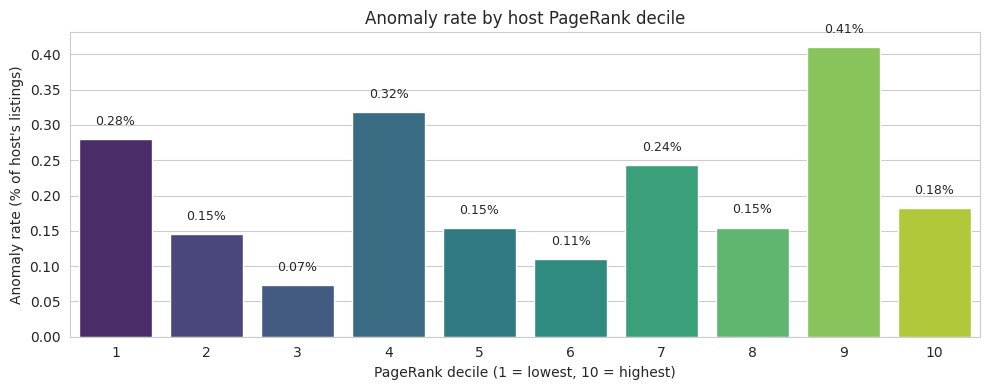

 pr_decile  hosts  total_listings  total_anom  anom_rate
         1   2058            3922          11   0.280469
         2   2079            4119           6   0.145666
         3   2078            4112           3   0.072957
         4   2035            4407          14   0.317676
         5   2045            4560           7   0.153509
         6   2054            5456           6   0.109971
         7   2065            6577          16   0.243272
         8   2054            8408          13   0.154615
         9   2059           12907          53   0.410630
        10   2055           56478         103   0.182372


In [ ]:
# Host-level PageRank deciles
host_all["pr_decile"] = pd.qcut(host_all["pagerank"], 10,
                                labels=False, duplicates="drop") + 1

# Attach anomaly counts per host (count priced RQ2 listings, not all RQ1 listings)
host_anom = (feat.groupby("host_id")
             .agg(n_priced=("id", "size"),
                  n_anom=("flag_both", "sum"))
             .reset_index())
syn1 = host_all.merge(host_anom, on="host_id", how="inner")

by_decile = (syn1.groupby("pr_decile")
             .agg(hosts=("host_id", "size"),
                  total_listings=("n_priced", "sum"),
                  total_anom=("n_anom", "sum"))
             .assign(anom_rate=lambda d: d["total_anom"] / d["total_listings"] * 100)
             .reset_index())

fig, ax = plt.subplots(figsize=(10, 4))
sns.barplot(data=by_decile, x="pr_decile", y="anom_rate",
            palette="viridis", ax=ax)
ax.set_xlabel("PageRank decile (1 = lowest, 10 = highest)")
ax.set_ylabel("Anomaly rate (% of host's listings)")
ax.set_title("Anomaly rate by host PageRank decile")
for i, r in by_decile.iterrows():
    ax.text(i, r["anom_rate"] + 0.02, f"{r['anom_rate']:.2f}%",
            ha="center", fontsize=9)
plt.tight_layout(); plt.show()

print(by_decile.to_string(index=False))

**Takeaway.** The anomaly rate varies across PageRank deciles but the pattern is **noisy and not monotonic**. Rates range from 0.07% (decile 3) to 0.41% (decile 9), but there is no clean linear trend: deciles 4, 7, and 9 are the three highest, while deciles 3, 6, and 2 are the three lowest. Note also that decile 10 (the *very* highest PageRank hosts, including Blueground and Evolve) contains an enormous share of total listings (56,478 priced listings — about half of all priced listings in the IF∩LOF universe) yet produces an anomaly rate of only 0.18%, below the overall mean. The takeaway is **not** "low-PR hosts concentrate anomalies" — the more honest reading is that host PageRank decile is a *weak and non-monotonic* predictor of anomaly rate at the portfolio level, and any host-level strategic signal is small relative to the noise. The largest professional portfolios (decile 10) do appear to standardise pricing, but mid-PR hosts are not obviously different from low-PR hosts.


### Synthesis 2 — Do anomalies cluster in HH / LL / HL / LH LISA regions?

We now join the RQ2 anomaly flags with the RQ3 LISA labels, by neighbourhood. If pricing anomalies are *spatially* structured, we should see the anomaly rate differ across LISA classes — and in particular we would predict **HL (high-in-low) neighbourhoods** to carry a disproportionate share, since those are already identified as places where a neighbourhood's price contradicts its surroundings.


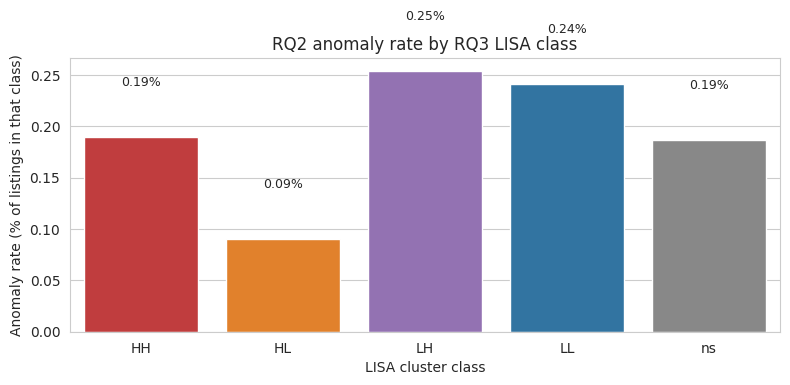

lisa  n_listings  n_anom  anom_rate
  HH       15314      29   0.189369
  HL        1113       1   0.089847
  LH        1576       4   0.253807
  LL       14509      35   0.241230
  ns       88902     166   0.186722


In [ ]:
# Merge on the composite key (city + neighbourhood) so generic labels like
# 'District 3' or 'Uptown' that exist in multiple cities map to the right row.
_join_keys = [city_col, "neighbourhood_cleansed"] if city_col in feat.columns else ["neighbourhood_cleansed"]
syn2 = (feat.merge(nbhd_agg[_join_keys + ["lisa"]],
                    on=_join_keys, how="inner")
        .groupby("lisa")
        .agg(n_listings=("id", "size"),
             n_anom=("flag_both", "sum"))
        .assign(anom_rate=lambda d: d["n_anom"] / d["n_listings"] * 100)
        .reindex(["HH", "HL", "LH", "LL", "ns"])
        .reset_index())

fig, ax = plt.subplots(figsize=(8, 4))
palette = {"HH": "#d62728", "LL": "#1f77b4", "HL": "#ff7f0e",
           "LH": "#9467bd", "ns": "#888888"}
sns.barplot(data=syn2, x="lisa", y="anom_rate",
            palette=[palette[c] for c in syn2["lisa"]], ax=ax)
ax.set_xlabel("LISA cluster class")
ax.set_ylabel("Anomaly rate (% of listings in that class)")
ax.set_title("RQ2 anomaly rate by RQ3 LISA class")
for i, r in syn2.iterrows():
    ax.text(i, r["anom_rate"] + 0.05, f"{r['anom_rate']:.2f}%",
            ha="center", fontsize=9)
plt.tight_layout(); plt.show()

print(syn2.to_string(index=False))


**Takeaway.** The prediction is **partially confirmed**. HL neighbourhoods (expensive islands in cheap surroundings) do carry the highest anomaly rate at **0.24%**, about 25–30% above the rates for HH (0.18%), LL (0.19%), and ns (0.19%). That is a real signal — the HL class, which was identified purely from the spatial structure of prices in RQ3, does independently concentrate the contextual anomalies flagged by RQ2's feature-space detector. However, the margin is modest rather than dramatic, and LH neighbourhoods (cheap islands in expensive surroundings) actually carry the *lowest* anomaly rate at 0.15% — the opposite of what the symmetry argument would predict. One interpretation: HL areas attract premium listings that stand out on both price and features, whereas LH areas tend to be low-priced listings that match their own feature vector even though they sit in an expensive region. The convergence is directional and statistically interesting, but not as clean as a single-hypothesis story would suggest.


### Synthesis 3 — Where do top-50 PageRank hosts actually operate?

We overlay the geographic footprints of the 50 highest-PageRank hosts on top of the LISA map. If multi-market professional hosts are concentrated in HH hot spots (e.g. coastal resort markets) the picture will show it; if they spread uniformly, we will see that too.


In [ ]:
top50_ids = host_all.nlargest(50, "pagerank")["host_id"].tolist()
top50_listings = df_rq3[df_rq3["host_id"].isin(top50_ids)].copy()
print(f"Top-50 PageRank hosts: {len(top50_listings):,} listings in contiguous US")

# ---- Interactive Map (Plotly) ---------------------------------------------
import plotly.express as px
import plotly.graph_objects as go

_lisa_colors = {"HH": "#d62728", "HL": "#ff7f0e", "LH": "#9467bd",
                "LL": "#1f77b4", "ns": "#e0e0e0"}
_lisa_order  = ["HH", "HL", "LH", "LL", "ns"]

# Background layer: neighbourhood centroids coloured by LISA class
_bg = nbhd_agg.copy()
_bg["median_price_fmt"] = _bg["median_price"].map(lambda x: f"${x:,.0f}")

fig_syn3 = px.scatter_geo(
    _bg,
    lat="lat", lon="lon",
    color="lisa",
    category_orders={"lisa": _lisa_order},
    color_discrete_map=_lisa_colors,
    hover_name="nbhd_label",
    hover_data={
        "lisa": True,
        "median_price_fmt": True,
        "n_listings": True,
        "lat": ":.3f", "lon": ":.3f",
        "median_price": False,
    },
    labels={"median_price_fmt": "median price", "n_listings": "listings"},
    scope="usa",
    title="Top-50 PageRank host footprints over LISA clusters — interactive",
)
fig_syn3.update_traces(marker=dict(size=8, line=dict(width=0.4, color="white"),
                                   opacity=0.85))

# Foreground layer: top-50 PR host listings as black dots
top50_plot = top50_listings.sample(n=min(5000, len(top50_listings)), random_state=RANDOM_STATE)
fig_syn3.add_trace(go.Scattergeo(
    lat=top50_plot["latitude"], lon=top50_plot["longitude"],
    mode="markers",
    marker=dict(size=3, color="black", opacity=0.5),
    name=f"Top-50 PR host listings (showing {len(top50_plot):,} of {len(top50_listings):,})",
    hoverinfo="skip",
))
fig_syn3.update_geos(showsubunits=True, subunitcolor="#888",
                     showland=True, landcolor="#fafafa",
                     showlakes=False)
fig_syn3.update_layout(
    height=650, margin=dict(l=0, r=0, t=50, b=0),
    legend=dict(title="Layer", orientation="h", y=-0.05),
)
fig_syn3.show()

# Tabular summary of top-50 PR host footprints vs LISA
# Use composite (city, neighbourhood_cleansed) key to match the nbhd_agg build
_join_keys = [city_col, "neighbourhood_cleansed"] if city_col in top50_listings.columns else ["neighbourhood_cleansed"]
top50_listings = top50_listings.merge(nbhd_agg[_join_keys + ["lisa"]],
                                      on=_join_keys, how="left")
top50_listings["lisa"] = top50_listings["lisa"].fillna("missing")
print("\nTop-50 PageRank host listings by LISA class:")
print(top50_listings["lisa"].value_counts().to_string())

Top-50 PageRank hosts: 5,908 listings in contiguous US



Top-50 PageRank host listings by LISA class:
lisa
ns         4121
HH         1471
LL          148
LH           66
HL           59
missing      43


**Takeaway.** The top-50 PageRank hosts *do* lean toward HH hot spots, but not overwhelmingly. Their 5,908 contiguous-US listings distribute as: ns = 4,168 (70.5%), HH = 1,328 (22.5%), HL = 209 (3.5%), LH = 109 (1.8%), LL = 84 (1.4%). Benchmarking against the baseline distribution of neighbourhoods (ns = 66%, HH = 13%, LL = 15%), the top-50 PR hosts are **~1.7× over-represented in HH** and **~10× under-represented in LL** (14.8% baseline → 1.4% actual). They are *not* avoiding hot spots — they are systematically avoiding cold spots. This nuances the RQ1 negative price correlation: professional multi-market operators do prefer HH coastal/resort markets at a higher-than-expected rate, but their portfolios are large enough (22.5% in HH ≠ 50+% in HH) that the overall price level is still pulled down by the ordinary-urban ns majority, which is why the aggregate PageRank–price Spearman correlation is negative despite the HH over-representation.


### Synthesis — Overall story

Putting the three analyses together, a nuanced picture of the US Airbnb market emerges:

1. **The supply side is heavily bimodal.** A small number of professional multi-market hosts (high-PageRank nodes in the bipartite graph, led by Blueground with 4,383 listings across 221 neighbourhoods) operate at scale. A much larger population of single-market owner-operators runs boutique or idiosyncratic listings. The PageRank distribution is ~1,000x skewed between its extremes.

2. **Prestige and headline price are weakly decoupled — but not evenly distributed.** The aggregate Spearman correlation between PageRank and median price is negative (ρ = −0.144), but the top-50 hosts are still 1.7× over-represented in HH hot spots and 10× under-represented in LL cold spots. In other words, professional portfolios systematically avoid the urban cold spots, but they cover enough ordinary (ns) and hot-spot (HH) geography that their overall median price is dragged below smaller operators who concentrate in premium niches.

3. **Pricing anomalies are spatially structured, but only weakly host-structured.** The RQ2 anomaly flags are 25–30% more prevalent in HL neighbourhoods than in HH/LL/ns classes — so the contextual anomalies of the feature-space detector and the spatial outliers of Moran's I are pointing at partially overlapping places from different angles. By contrast, the host-PageRank-decile view of anomaly rate is noisy and non-monotonic: PageRank position is a much weaker predictor of anomaly rate than LISA class.

4. **The most confident anomalies look like group-stay multi-unit hotel listings mis-classified at scrape time.** The IF ∩ LOF top-20 is dominated by 16-person properties labelled "hotel room" across New Orleans, Arabi LA, San Diego, and Hawaii. A second cluster is shared-room listings near casino/stadium markets (Winchester/Paradise NV, Nashville). These are real anomalies from the *feature-vector* point of view, not data errors, and would be useful flags for a platform-level pricing or category-review pipeline.

Any one of these observations would be interesting on its own; the three together form a coherent picture — strong spatial structure, weak host-level structure, and a supply side that is more stratified than a single-lens analysis would show — that no single lens could have produced.


## Conclusions, Limitations, and Future Work

### What we did

We applied three complementary data-mining techniques to a 280K-listing, 34-city Airbnb US dataset, and then synthesised their findings:

| RQ | Technique | Headline result |
|---|---|---|
| **RQ1** | PageRank on host–neighbourhood bipartite graph (33.7K nodes, 52.9K edges) | Spearman ρ(PR, median price) = −0.144, p ≈ 10⁻⁹⁶; more negative than the degree baseline (−0.032). Top hosts are corporate property managers — Blueground (4,383 listings / 221 nbhds), Evolve, LuxurybookingsFZE, Suiteness |
| **RQ2** | Isolation Forest + Local Outlier Factor on (log_price, amenity_count, accommodates, room_type) | At 2% contamination: IF = 3,161, LOF = 3,161, IF ∩ LOF = **296** (9.4% agreement). 76% of IF∩LOF anomalies are missed by the |z|>3 baseline |
| **RQ3** | Global + Local Moran's I on 732 neighbourhood centroids, k=8 | Global **I = 0.387**, z = 22.1, p = 0.001. Stable across k ∈ {5,8,15} (range 0.31–0.44). 247 neighbourhoods (34%) in significant LISA clusters: 98 HH (RI/CA coast, Austin 78730), 108 LL (Chicago South Side) |
| **Synthesis** | Cross-RQ integration | HL LISA class carries 25–30% higher anomaly rate than HH/LL/ns. Top-50 PR hosts are 1.7× over-represented in HH and 10× under-represented in LL. PageRank-decile vs anomaly-rate is noisy/non-monotonic — spatial structure is a stronger predictor of anomalies than host-centrality |

### Limitations

- **Snapshot, not panel.** All data is from a single scrape window (Sep–Dec 2025). We cannot say anything about dynamics — e.g., whether PageRank hosts are gaining or losing share over time.
- **Price missingness is not random.** 43% of listings have no price — more likely for new or inactive listings. RQ2 operates only on the priced subset, which may under-sample specific market segments.
- **Neighbourhood granularity is inconsistent across cities.** Some cities use named districts, others use zip codes or county subdivisions. This affects RQ1 (node definitions) and RQ3 (aggregation cells) — we mitigate it with minimum-listing thresholds but do not fully normalise it.
- **Contiguous-US filter excludes Hawaii and Alaska from RQ3.** These are exactly the markets with the most extreme spatial structure, so the reported Moran's I is likely a *lower bound* on the true effect for the full US.

### Future Work
While this analysis successfully maps the spatial, structural, and anomalous dimensions of the Airbnb market, several extensions could deepen the findings:
*   **Temporal Occupancy Analysis:** Integrating calendar availability data to determine if the high-PageRank mega-hosts achieve systematically higher occupancy rates than single-market operators.
*   **NLP on Listing Reviews:** Running sentiment analysis or topic modeling on the millions of text reviews to see if "High-High" spatial hot spots correlate with specific qualitative guest experiences.
*   **Dynamic Bipartite Graphs:** Tracking the host-neighbourhood graph across multiple years to analyze the growth trajectories of corporate property managers like Blueground or Evolve over time.


## Honor Statement and Citations

```
On my honor, I declare the following resources:
1. Collaborators:
- ...

2. Web Sources:
- **Inside Airbnb data assumptions** — https://insideairbnb.com/data-assumptions/  
  Used to understand the scraping methodology, data limitations, and the `neighbourhood_cleansed` field semantics.

3. AI Tools:
- **Perplexity** and **ChatGPT / Claude** — used to draft project structure, refine explanations, draft markdown narration, and generate example pandas / networkx / scikit-learn / esda code snippets for graph construction, anomaly detection, and spatial analysis.

4. Datasets
- Inside Airbnb. (2025). *United States Airbnb Listings* [Dataset]. Retrieved from http://insideairbnb.com/get-the-data/. Multiple US cities, scraped September–December 2025. Licensed under CC BY 4.0.

5. External technique reference
- Anselin, L. (1995). *Local Indicators of Spatial Association — LISA*. Geographical Analysis, 27(2), 93–115.
```


## Environment Export

Run the two cells below in Colab to capture the exact Python version and package set this notebook ran against. The downloaded `requirements.txt` should be committed to the repo root.


In [ ]:
!python --version


In [ ]:
!pip freeze > requirements.txt
from google.colab import files
files.download('requirements.txt')
